In [1]:
from mylib.statistic_test import *
# Gaussian smoothing
from scipy.ndimage import gaussian_filter
from sklearn.cluster import KMeans

code_id = "0867 - Manifold Attractiveness"
loc = join(figpath, "Dsp", code_id)
mkdir(loc)

dir_name = join(figpath, "Dsp", "Reforming Neural Trajectory Analysis") # 存了每只鼠neural trajecoty: join(dir_name, "10232.pkl")
dir_name0 = join(figpath, "Dsp", "0850 - Lisa Paper Revisits")

d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


        D:\Data\FinalResults\Dsp\0867 - Manifold Attractiveness is already existed!


In [2]:
def fit_kmeans(X, R: int, kmeans_init=None, is_return_model: bool = False):
    """
    Cluster Maps with KMeans model.
    
    Parameters
    ----------
    X : np.ndarray
        The entire map of this cell within this session.
        shape: (I x J x K) tensor of normalized firing rates
        
        I: Trials
        J: Spatial bins
        K: Neurons
    
    Returns
    -------
    U, V
    """
    X_wrap = np.reshape(X, (X.shape[0], X.shape[1]*X.shape[2]))
    
    if kmeans_init is not None:
        kmean = KMeans(n_clusters=R, init=kmeans_init)
    else:
        kmean = KMeans(n_clusters=R)
        
    kmean.fit(X_wrap)
    
    U = np.zeros((X.shape[0], R))
    for i in range(X.shape[0]):
        U[i, kmean.labels_[i]] = 1
        
    V = kmean.cluster_centers_
    
    if R == 2 and is_return_model == False:
        nclusters = np.sum(U, axis=0)
        if nclusters[0] < nclusters[1]:
            print(f"{nclusters[0]} < {nclusters[1]}")
            U = U[:, [1, 0]]
            V = V[[1, 0], :]
    
    if is_return_model:
        return U, V, kmean
    else:
        return U, V

# R4

In [3]:

def cosine_similarity(a, b):
    a_norm = np.linalg.norm(a)
    b_norm = np.linalg.norm(b)
    if a_norm == 0 or b_norm == 0:
        return 0.0
    return np.dot(a, b) / (a_norm * b_norm)

def process_data(mouse:int):
    maze_type = 1
    if exists(join(loc, f"processed_{mouse}.pkl")):
        with open(join(loc, f"processed_{mouse}.pkl"), 'rb') as f:
            data = pickle.load(f)
    else:
        file_idx = np.where((f2['MiceID'] == mouse))[0]
        
        with open(join(dir_name, f"{mouse}.pkl"), 'rb') as f:
            res = pickle.load(f)
            
        with open(f_CellReg_dsp['cellreg_folder'][np.where(f_CellReg_dsp['MiceID'] == mouse)[0][0]], 'rb') as f:
            index_map = pickle.load(f).astype(np.int64)
            
        if mouse not in [10232, 10275, 10276]:
            index_map = index_map[1:, :] 
        
        with open(join(dir_name0, f"{mouse}.pkl"), "rb") as f:
            X, session_label, route_label, kmeans_init = pickle.load(f)
        print(X.shape)
        #kmeans_init = #np.vstack([np.mean(i, axis=0) for i in kmeans_init])
        #U, V = fit_kmeans(X, 2, kmeans_init=kmeans_init)
        #V0 = np.reshape(V[0, :], (CP_DSPs[maze_type][3].shape[0], -1))
        #V1 = np.reshape(V[1, :], (CP_DSPs[maze_type][3].shape[0], -1))
        
        is_cell = np.where(index_map != 0, 1, 0)
        n_cells = np.sum(is_cell, axis=0)
        cell_idx = np.where(n_cells == 7)[0]
        
        data = {
            'neural_traj': [],
            'speed_traj': [],
            'corr_traj': [],
            'session_traj': [],
            'lap_traj': [],
            'route_traj': [],
            'pos_traj': [],
            'org_to_now_idx': [],
            'is_correct_heading_traj': [],
            'part_traj': []
        }
        print(mouse)
        for s in range(7):
            if s == 1 and mouse in [10212, 10227]:
                continue
            
            with open(f2['Trace File'][file_idx[s]], 'rb') as f:
                trace = pickle.load(f)  
                
                
            session_traj = res['session_traj']
            nodes_traj = res['pos_traj']
            father_nodes_traj = S2F[nodes_traj]-1
            idx = np.where((session_traj == s) & (np.isin(father_nodes_traj+1, CP_DSPs[maze_type][3])))[0]
            first_idx_in_this_session = np.where(session_traj == s)[0][0]
            idx_for_neural = idx[idx>=first_idx_in_this_session] - first_idx_in_this_session
            session_traj = session_traj[idx]
            nodes_traj = nodes_traj[idx]
            assert nodes_traj.min() >= 0 and nodes_traj.max() <= 2303
            neural_traj = res['neural_traj_list'][s][:, idx_for_neural]
            father_nodes_traj = father_nodes_traj[idx]
            speed_traj = res['behav_params_traj'][8, res['behav_to_ms_traj']][idx]
            heading_traj = res['behav_params_traj'][4, res['behav_to_ms_traj']][idx]
            template_heading = res['behav_params_templ_traj'][2, res['behav_to_ms_traj']][idx]
            lap_traj = res['lap_traj'][idx]
            route_traj = res['route_traj'][idx]
            part_traj = res['part_traj'][idx]
            
            # Use only the data points where the animal is moving in a direction
            # roughly consistent with the template trajectory
            res_heading = (heading_traj - template_heading)
            res_heading[res_heading < 0] += 2*np.pi
            assert res_heading.min() >= 0 and res_heading.max() < 2*np.pi
            res_heading[res_heading > np.pi] = 2*np.pi - res_heading[res_heading > np.pi]
            is_correct_heading_traj = np.where(res_heading < np.pi/2, 1, 0)
            
            ratemap0_a = trace[f'node {0}']['smooth_map_all']
            
            ratemap0_b = trace[f'node {5}']['smooth_map_all']
            pc_idx0_b = (trace[f'node {5}']['is_placecell'] == 1)
            ratemap0 = np.stack([ratemap0_a, ratemap0_b], axis=2)
            
            ratemap4 = trace[f'node {3}']['smooth_map_all'] 
            
            corr_coord = np.zeros((route_traj.shape[0], 2))
            for i in tqdm(range(len(route_traj))):
                corr_coord[i, 0] = np.corrcoef(
                    neural_traj[:, i], 
                    ratemap0[:, nodes_traj[i], part_traj[i]]
                )[0, 1]
                corr_coord[i, 1] = np.corrcoef(
                    neural_traj[:, i], 
                    ratemap4[:, nodes_traj[i]]
                )[0, 1]
            
            data['neural_traj'].append(neural_traj)
            data['speed_traj'].append(speed_traj)
            data['corr_traj'].append(corr_coord)
            data['session_traj'].append(session_traj)
            data['lap_traj'].append(lap_traj)
            data['route_traj'].append(route_traj)
            data['pos_traj'].append(nodes_traj)
            data['org_to_now_idx'].append(idx)
            data['is_correct_heading_traj'].append(is_correct_heading_traj)
            data['part_traj'].append(part_traj)
            
        data['speed_traj'] = np.concatenate(data['speed_traj'])
        data['corr_traj'] = np.concatenate(data['corr_traj'], axis=0).T
        data['session_traj'] = np.concatenate(data['session_traj'])
        data['lap_traj'] = np.concatenate(data['lap_traj'])
        data['route_traj'] = np.concatenate(data['route_traj'])
        data['pos_traj'] = np.concatenate(data['pos_traj'])
        data['org_to_now_idx'] = np.concatenate(data['org_to_now_idx'])
        data['is_correct_heading_traj'] = np.concatenate(data['is_correct_heading_traj'])
        data['part_traj'] = np.concatenate(data['part_traj'])
        
        with open(join(loc, f"processed_{mouse}.pkl"), 'wb') as f:
            pickle.dump(data, f)
    
    idx = np.where(
        (np.isnan(data['corr_traj'][0, :]) == False) &
        (np.isnan(data['corr_traj'][1, :]) == False)
    )[0]
    
    for k in data.keys():
        if k == 'neural_traj':
            continue
        if data[k].ndim == 1:
            data[k] = data[k][idx]
        elif data[k].ndim == 2:
            data[k] = data[k][:, idx]
    
    return data

def plot_vector_field(mouse: int, is_shuf: bool = False):
    res = process_data(mouse)

    lap_traj = res['lap_traj']
    beg = np.concatenate([[0], np.where(np.diff(lap_traj) != 0)[0] + 1])
    end = np.concatenate([np.where(np.diff(lap_traj) != 0)[0] + 1, [len(lap_traj)]])
    corr_traj = res['corr_traj']
    is_correct_heading_traj = res['is_correct_heading_traj']
    
    if is_shuf:
        
        rand_idx = np.random.permutation(corr_traj.shape[1])
        corr_traj = corr_traj[:, rand_idx]
    
    speed_traj = res['speed_traj']
    speed_binned = np.clip(speed_traj // 10, 0, 4).astype(np.int64)
    dcorr = np.zeros_like(corr_traj) * np.nan

    for i in range(len(beg)):
        dcorr[:, beg[i]:end[i]-1] = np.diff(corr_traj[:, beg[i]:end[i]], axis=1)

    x_binned = np.clip((corr_traj[0, :] + 0.1) // 0.05, 0, 19).astype(np.int64)
    y_binned = np.clip((corr_traj[1, :] + 0.1) // 0.05, 0, 19).astype(np.int64)

    avg_dcorr = np.zeros((20, 20, 5, 3))
    for sp in range(5):
        for i in range(20):
            for j in range(20):
            
                idx = np.where(
                    (x_binned == i) & 
                    (y_binned == j) & 
                    (speed_binned == sp) & 
                    (np.isnan(dcorr[0, :]) == False) &
                    (np.isnan(dcorr[1, :]) == False) &
                    (is_correct_heading_traj == 1)
                )[0]
                if len(idx) > 0:
                    avg_dx = np.nanmean(dcorr[0, idx])
                    avg_dy = np.nanmean(dcorr[1, idx])
                    strength = np.sqrt(avg_dx**2 + avg_dy**2)
                    avg_dcorr[i, j, sp, 0] = avg_dx #/ strength if strength != 0 else 0
                    avg_dcorr[i, j, sp, 1] = avg_dy #/ strength if strength != 0 else 0
                    avg_dcorr[i, j, sp, 2] = strength
        
        idx0 = np.where(avg_dcorr[:, :, sp, 0] == 0)
        idx1 = np.where(avg_dcorr[:, :, sp, 1] == 0)
        avg_dcorr[:, :, sp, 0] = gaussian_filter(avg_dcorr[:, :, sp, 0], sigma=1)
        avg_dcorr[:, :, sp, 0][idx0] = 0
        avg_dcorr[:, :, sp, 1] = gaussian_filter(avg_dcorr[:, :, sp, 1], sigma=1)
        avg_dcorr[:, :, sp, 1][idx1] = 0
        strength = np.sqrt(
            avg_dcorr[:, :, sp, 0]**2 + avg_dcorr[:, :, sp, 1]**2
        )
        strength[strength < 1e-8] = 1e-8
        avg_dcorr[:, :, sp, 0] /= strength
        avg_dcorr[:, :, sp, 0][idx0] = 0
        avg_dcorr[:, :, sp, 1] /= strength
        avg_dcorr[:, :, sp, 1][idx1] = 0

    X, Y = np.meshgrid(np.arange(20), np.arange(20))

    fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(15, 5))
    sp = [0, 2, 4]
    for i in range(3):
        
        ax = Clear_Axes(axes[i], close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
        ax.quiver(
            Y.flatten(), X.flatten(), 
            avg_dcorr[:, :, sp[i], 0].flatten(), 
            avg_dcorr[:, :, sp[i], 1].flatten(), 
            avg_dcorr[:, :, sp[i], 2],
            scale=20, width=0.007       
        )
        ax.set_xticks(np.linspace(-0.5, 19.5, 6), [-0.1, 0.1, 0.3, 0.5, 0.7, 0.9])
        ax.set_yticks(np.linspace(-0.5, 19.5, 6), [-0.1, 0.1, 0.3, 0.5, 0.7, 0.9])
        ax.set_aspect('equal')
        ax.set_xlim(-0.5, 19.5)
        ax.set_ylim(-0.5, 19.5)
    
    plus = '' if is_shuf == False else ' (shuffled)'
    plt.savefig(join(loc, f"Example Vector Field [{mouse}{plus}].png"), dpi=600)
    plt.savefig(join(loc, f"Example Vector Field [{mouse}{plus}].svg"), dpi=600)
    plt.show()

for mouse in [10212, 10224, 10227, 10232, 10275, 10276]:
    process_data(mouse)
    #plot_vector_field(mouse, is_shuf=False)

# Test Cross-Manifold Transitions

In [122]:
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
# Normalize
from sklearn.preprocessing import StandardScaler

mouse = 10276
with open(join(dir_name, f"{mouse}.pkl"), 'rb') as f:
    res = pickle.load(f)
    
lap_traj = res['lap_traj']
route_traj = res['route_traj']
session_traj = res['session_traj']
neural_trajs = res['neural_traj_list']
nodes_traj = res['pos_traj']
heading_traj = res['behav_params_traj'][4, res['behav_to_ms_traj']]
template_heading = res['behav_params_templ_traj'][2, res['behav_to_ms_traj']]
res_heading = (heading_traj - template_heading)
res_heading[res_heading < 0] += 2*np.pi
assert res_heading.min() >= 0 and res_heading.max() < 2*np.pi
res_heading[res_heading > np.pi] = 2*np.pi - res_heading[res_heading > np.pi]
is_correct_heading_traj = np.where(res_heading < np.pi/2, 1, 0)

s = 6
idx = np.where((session_traj == s)&(is_correct_heading_traj == 1))[0]
session_traj = session_traj[idx]
lap_traj = lap_traj[idx]
route_traj = route_traj[idx]
nodes_traj = nodes_traj[idx]
neural_traj = neural_trajs[s]
part_traj = res['part_traj'][idx]

# Normalize the neural trajectory
scaler = StandardScaler()
neural_traj = scaler.fit_transform(neural_traj.T).T

pca = PCA(n_components=1)
pca.fit_transform(neural_traj.T)

q_traj = np.zeros(nodes_traj.shape[0])*np.nan

for pt in range(2):
    idx = np.where(part_traj==pt)[0]
    print(f"{time.strftime('%Y-%m-%d %H:%M:%S')} - Part {pt}")
    for i in tqdm(CP_DSPs[1][0]):
        idx = np.where((S2F[nodes_traj] == i)&(part_traj==pt))[0]
        r0_idx = np.where((S2F[nodes_traj] == i)&(route_traj==0)&(part_traj==pt))[0]
        
        if len(idx) < 3:
            continue
        
        q_traj[idx] = pca.transform(neural_traj[:, idx].T)[:, 0]
        
        if np.median(q_traj[r0_idx]) > 0:
            q_traj[idx] = -q_traj[idx]
        
        mean = np.median(q_traj[r0_idx])
        std = np.std(q_traj[r0_idx])
        q_traj[idx] = np.clip((q_traj[idx] - mean) / std, -10, 10)

2026-05-28 22:12:49 - Part 0


100%|██████████| 111/111 [00:00<00:00, 3054.45it/s]


2026-05-28 22:12:49 - Part 1


100%|██████████| 111/111 [00:00<00:00, 2157.37it/s]


In [120]:
print(np.where(part_traj==0)[0].shape, np.where(part_traj==1)[0].shape)

(4367,) (11155,)


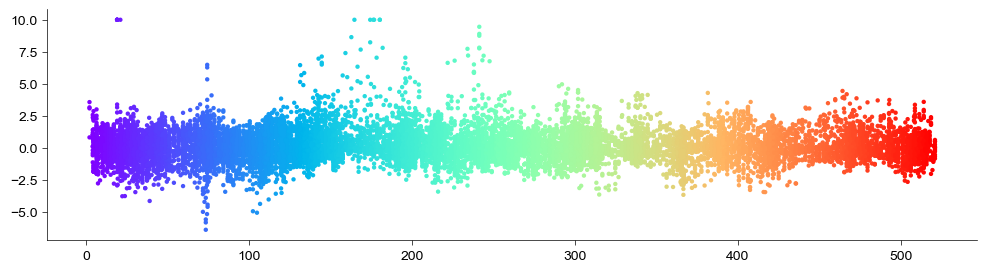

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_34128\3677727727.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(dist_traj, q_traj,  c=DSPPaletteRGBA[route_traj], s=10, edgecolors='none', cmap='rainbow')


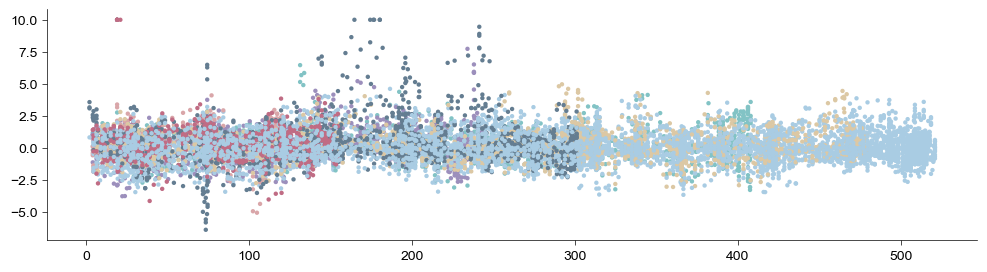

In [123]:
dlap_traj = np.diff(lap_traj)
beg = np.concatenate([[0], np.where(dlap_traj != 0)[0] + 1])
end = np.concatenate([np.where(dlap_traj != 0)[0] + 1, [len(lap_traj)]])
D = GetDMatrices(1, 48)
dist_traj = D[nodes_traj, 2303]

fig = plt.figure(figsize=(12, 3))
ax = Clear_Axes(plt.subplot(111), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
scatter = ax.scatter(dist_traj, q_traj,  c=dist_traj, s=10, edgecolors='none', cmap='rainbow')
plt.show()

fig = plt.figure(figsize=(12, 3))
ax = Clear_Axes(plt.subplot(111), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
scatter = ax.scatter(dist_traj, q_traj,  c=DSPPaletteRGBA[route_traj], s=10, edgecolors='none', cmap='rainbow')
plt.show()

In [ ]:
# 

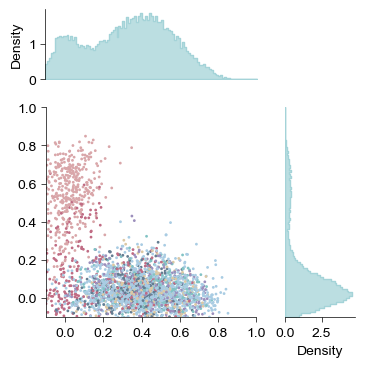

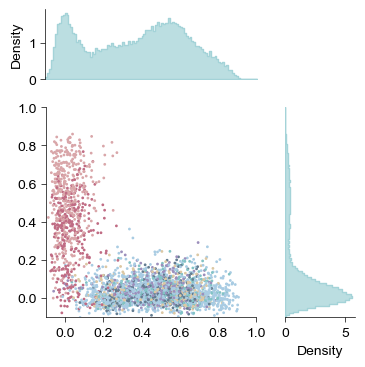

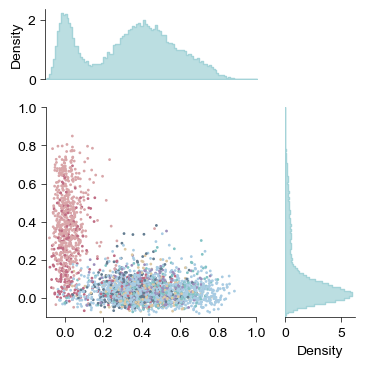

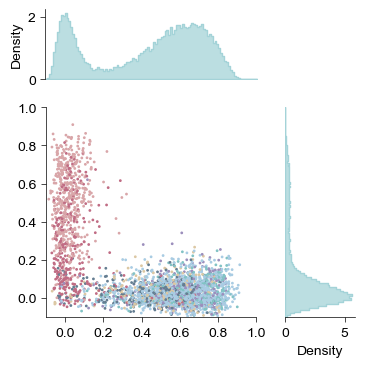

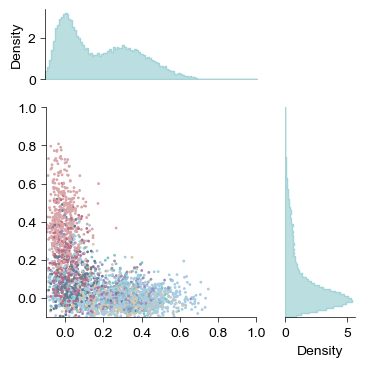

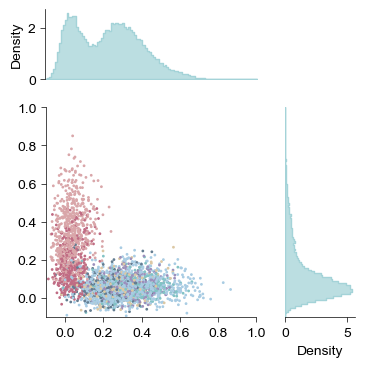

In [155]:
for mouse in [10212, 10224, 10227, 10232, 10275, 10276]:
    res = process_data(mouse)
    lap_traj = res['lap_traj']
    speed_traj = res['speed_traj']
    session_traj = res['session_traj']
    beg = np.concatenate([[0], np.where(np.diff(lap_traj) != 0)[0] + 1])
    end = np.concatenate([np.where(np.diff(lap_traj) != 0)[0] + 1, [len(lap_traj)]])
    corr_traj = res['corr_traj']
    route_traj = res['route_traj']
    is_correct_heading_traj = res['is_correct_heading_traj']

    fig, axes = plt.subplots(
        ncols=2, nrows=2, figsize=(4, 4), 
        gridspec_kw={'width_ratios': [3, 1], 'height_ratios': [1, 3]}
    )
    ax = Clear_Axes(axes[1, 0], close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    # Set randdom seeds
    np.random.seed(42)
    rand_idx = np.random.choice(np.where(is_correct_heading_traj == 1)[0], size=3000, replace=False)
    ax.scatter(
        corr_traj[0, rand_idx], corr_traj[1, rand_idx], 
        s=1, c=DSPPaletteRGBA[route_traj[rand_idx], :],
        edgecolors=None
    )
    ax.set_aspect('equal')
    ax.axis([-0.1, 1, -0.1, 1])
    ax.set_xticks(np.linspace(0, 1, 6))

    Clear_Axes(axes[0, 1])

    ax0 = Clear_Axes(axes[0, 0], close_spines=['top', 'right', 'bottom'], ifyticks=True)
    sns.histplot(
        x=corr_traj[0, :], 
        bins=np.linspace(-0.1, 1, 111), 
        color="#a4d3d8",
        stat='density', 
        element='step',
        ax=ax0
    )
    ax0.set_xlim(-0.1, 1)

    ax1 = Clear_Axes(axes[1, 1], close_spines=['top', 'right', 'left'], ifxticks=True)
    sns.histplot(
        y=corr_traj[1, :], 
        bins=np.linspace(-0.1, 1, 111), 
        color="#a4d3d8",
        stat='density', 
        element='step',
        ax=ax1
    )
    ax1.set_ylim(-0.1, 1)
    plt.savefig(join(loc, f'Example Paired Correlation [{mouse}].png'), dpi=600)
    plt.savefig(join(loc, f'Example Paired Correlation [{mouse}].svg'), dpi=600)
    plt.show()

# Visualize how to compute flow fields

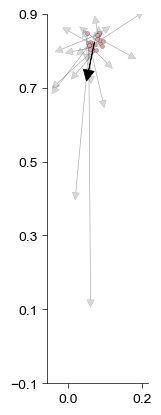

In [65]:
res = process_data(10232)
lap_traj = res['lap_traj']
speed_traj = res['speed_traj']
session_traj = res['session_traj']
beg = np.concatenate([[0], np.where(np.diff(lap_traj) != 0)[0] + 1])
end = np.concatenate([np.where(np.diff(lap_traj) != 0)[0] + 1, [len(lap_traj)]])
corr_traj = res['corr_traj']
route_traj = res['route_traj']

idx = np.where(
    (corr_traj[1, :] >= 0.8) &
    (corr_traj[1, :] < 0.85) &
    (corr_traj[0, :] >= 0.05) &
    (corr_traj[0, :] < 0.1)
)[0]
x = corr_traj[:, idx]
y = corr_traj[:, idx+1]

fig = plt.figure()
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax.scatter(x[0, :], x[1, :], c=DSPPalette[3], edgecolors='k', linewidth=0.15,s=8, zorder=1)
for i in range(len(idx)):
    ax.arrow(
        x[0, i], x[1, i],
        y[0, i] - x[0, i], y[1, i] - x[1, i],
        head_width=0.02, head_length=0.02, fc='gray', ec=None, linewidth=0.2,
        zorder=0,
        alpha=0.3
    )
avg = np.mean(x, axis=1)
avg_d = np.mean(y - x, axis=1)
ax.arrow(
    avg[0], avg[1],
    avg_d[0], avg_d[1],
    head_width=0.03, head_length=0.03, fc='k', ec=None, linewidth=0.5,
        zorder=1
)
ax.set_aspect('equal')
ax.set_ylim(-0.1, 0.9)
ax.set_yticks(np.linspace(-0.1, 0.9, 6))
plt.savefig(join(loc, "Example Paired Correlation [Flow Visualization 10232].png"), dpi=300)
plt.savefig(join(loc, "Example Paired Correlation [Flow Visualization 10232].svg"), dpi=300)
plt.show()

# Fit Attractor Strength

230



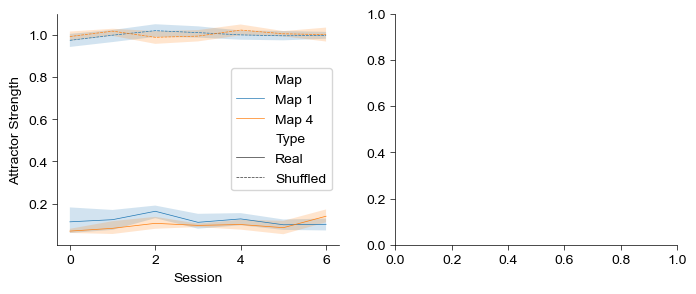

M1: 0.9192851635989467
M4: 0.8539757922267679
M1: 0.9998898624198054
M4: 0.9999968043036795


In [151]:

def fit_attractor_strength(mouse):
    res = process_data(mouse)
    lap_traj = res['lap_traj']
    beg = np.concatenate([[0], np.where(np.diff(lap_traj) != 0)[0] + 1])
    end = np.concatenate([np.where(np.diff(lap_traj) != 0)[0] + 1, [len(lap_traj)]])
    corr_traj = res['corr_traj']
    session_traj = res['session_traj']
    speed_traj = res['speed_traj']
    speed_binned = np.zeros_like(speed_traj).astype(np.int64)
    speed_binned[speed_traj < 10] = 0
    speed_binned[(speed_traj >= 10) & (speed_traj < 30)] = 1
    speed_binned[(speed_traj >= 30)] = 2
    is_correct_heading_traj = res['is_correct_heading_traj']
    route_traj = res['route_traj']
    part_traj = res['part_traj']
    
    speed_traj = res['speed_traj']
    speed_binned = np.clip(speed_traj // 20, 0, 2).astype(np.int64)
    dcorr = np.zeros_like(corr_traj) * np.nan

    for i in range(len(beg)):
        dcorr[:, beg[i]:end[i]-1] = np.diff(corr_traj[:, beg[i]:end[i]], axis=1)
    
    fitted_param = {
        "Session": [],
        "Route": [],
        "Attractor Strength": [],
        "Map": [],
        "Type": []
    }
    
    for s in range(7):
        for pt in range(2):
            for rt in [0,3]:
                if rt in [0, 1, 2, 4, 5]:
                    if rt == 5 and mouse == 10275:
                        continue
                    idx_m = np.where(
                        (session_traj == s) &
                        (np.isnan(dcorr[0, :]) == False) &
                        (np.isnan(dcorr[1, :]) == False) &
                        (is_correct_heading_traj == 1) &
                        (route_traj == rt) & 
                        (part_traj == pt)
                    )[0]
                    name_map = 'Map 1'
                    p_traj = corr_traj[0, :]
                    dc_traj = dcorr[0, :]
                elif rt == 3:
                    if mouse in [10212, 10224] and s == 1:
                        # In this session, both mice didn't remap or retrievals.
                        continue
                    idx_m = np.where(
                        (session_traj == s) &
                        (np.isnan(dcorr[0, :]) == False) &
                        (np.isnan(dcorr[1, :]) == False) &
                        (is_correct_heading_traj == 1) &
                        (route_traj == rt) &
                        (part_traj == pt)
                    )[0]
                    name_map = 'Map 4'
                    p_traj = corr_traj[1, :]
                    dc_traj = dcorr[1, :]
                else:
                    continue
            
                if idx_m.shape[0] > 10:
                    # Fit linear regression
                    center = np.mean(p_traj[idx_m])
                    x = center - p_traj[idx_m]
                    linreg_res = linregress(x, dc_traj[idx_m]).slope
                    fitted_param["Session"].append(s)
                    fitted_param["Attractor Strength"].append(linreg_res)
                    fitted_param["Map"].append(name_map)
                    fitted_param["Route"].append(rt)
                    fitted_param["Type"].append("Real")
                    
                    # Fit shuffled data
                    corr_shuf = corr_traj[:, idx_m][:, np.random.permutation(idx_m.shape[0])]
                    dcorr_shuf = np.hstack((np.diff(corr_shuf, axis=1), np.zeros((corr_shuf.shape[0], 1))))
                    p_traj_shuf = corr_shuf[0, :] if name_map == 'Map 1' else corr_shuf[1, :]
                    dc_traj_shuf = dcorr_shuf[0, :] if name_map == 'Map 1' else dcorr_shuf[1, :]
                    center_shuf = np.mean(p_traj_shuf)
                    x_shuf = center_shuf - p_traj_shuf

                    linreg_res_shuf = linregress(x_shuf, dc_traj_shuf).slope
                    fitted_param["Session"].append(s)
                    fitted_param["Attractor Strength"].append(linreg_res_shuf)
                    fitted_param["Map"].append(name_map)
                    fitted_param["Route"].append(rt)
                    fitted_param["Type"].append("Shuffled")
    
    return fitted_param

if exists(join(figdata, f" {code_id} [Attractor Strength].pkl")) == False:
    AttractorStrength = {
        "MiceID": [],
        "Session": [],
        "Route": [],
        "Attractor Strength": [],
        "Map": [],
        "Type": []
    }
    for mouse in [10212, 10224, 10227, 10232, 10275, 10276]:
        fitted_param = fit_attractor_strength(mouse)
        AttractorStrength["MiceID"].extend([mouse] * len(fitted_param["Session"]))
        AttractorStrength["Session"].extend(fitted_param["Session"])
        AttractorStrength["Attractor Strength"].extend(fitted_param["Attractor Strength"])
        AttractorStrength["Map"].extend(fitted_param["Map"])
        AttractorStrength["Route"].extend(fitted_param["Route"])
        AttractorStrength["Type"].extend(fitted_param["Type"])
    
    for k in AttractorStrength.keys():
        AttractorStrength[k] = np.array(AttractorStrength[k])
    
    with open(join(figdata, f"{code_id} [Attractor Strength].pkl"), 'wb') as f:
        pickle.dump(AttractorStrength, f)
    
    AttractorStrengthDF = pd.DataFrame(AttractorStrength)
    AttractorStrengthDF.to_excel(join(loc, "Attractor Strength.xlsx"), index=False)
    print(len(AttractorStrengthDF))
    print()
else:
    with open(join(figdata, f"{code_id} [Attractor Strength].pkl"), 'rb') as f:
        AttractorStrength = pickle.load(f)
        

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))
ax0 = Clear_Axes(axes[0], close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax1 = Clear_Axes(axes[1], close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x="Session",
    y="Attractor Strength",
    hue="Map",
    style="Type",
    data=AttractorStrength,
    linewidth=0.5,
    err_kws={"edgecolor": None},
    ax=ax0
)
plt.show()

print(f"M1: {linregress(AttractorStrengthDF[AttractorStrengthDF['Map'] == 'Map 1']['Session'], AttractorStrengthDF[AttractorStrengthDF['Map'] == 'Map 1']['Attractor Strength']).pvalue}")
print(f"M4: {linregress(AttractorStrengthDF[AttractorStrengthDF['Map'] == 'Map 4']['Session'], AttractorStrengthDF[AttractorStrengthDF['Map'] == 'Map 4']['Attractor Strength']).pvalue}")

datas1 = [AttractorStrength['Attractor Strength'][(AttractorStrength['Map'] == 'Map 1') & (AttractorStrength['Session'] == s)] for s in range(7)]
datas2 = [AttractorStrength['Attractor Strength'][(AttractorStrength['Map'] == 'Map 4') & (AttractorStrength['Session'] == s)] for s in range(7)]
print(f"M1: {f_oneway(*datas1).pvalue}")
print(f"M4: {f_oneway(*datas2).pvalue}" )

# For Session

100%|██████████| 6/6 [00:06<00:00,  1.16s/it]


31248


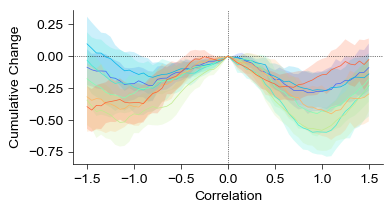

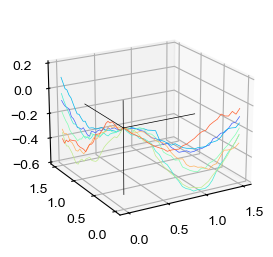

100%|██████████| 6/6 [00:00<00:00, 56.76it/s]


252
Speed 0
   R1: 0.9140734404002667
   R4: 0.5916943991385673
Speed 1
   R1: 0.5005591511955518
   R4: 0.013974468879926418
Speed 2
   R1: 0.5816485820355839
   R4: 4.54767996631491e-06


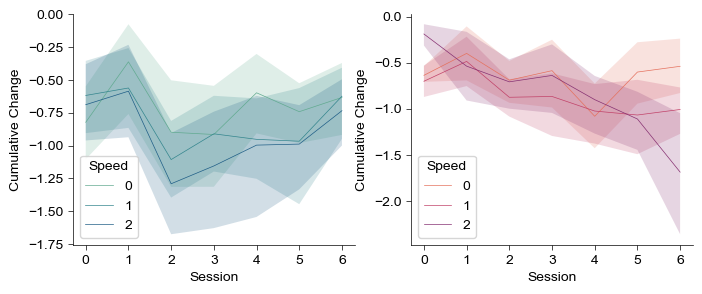

In [ ]:
def get_data_for_session(mouse: int, is_shuf: bool = False, sp: int = 1):
    res = process_data(mouse)
    
    lap_traj = res['lap_traj']
    beg = np.concatenate([[0], np.where(np.diff(lap_traj) != 0)[0] + 1])
    end = np.concatenate([np.where(np.diff(lap_traj) != 0)[0] + 1, [len(lap_traj)]])
    corr_traj = res['corr_traj']
    session_traj = res['session_traj']
    is_correct_heading_traj = res['is_correct_heading_traj']
    route_traj = res['route_traj']
    
    if is_shuf:
        rand_idx = np.random.permutation(corr_traj.shape[1])
        corr_traj = corr_traj[:, rand_idx]
    
    density_idx = np.where(
        (route_traj == 3) |
        (route_traj == 0)
    )[0]
    # Density Measure
    density_mat = scipy.stats.binned_statistic_2d(
        corr_traj[0, density_idx], corr_traj[1, density_idx], np.ones_like(corr_traj[0, density_idx]),
        statistic='sum', bins=[50, 50], range=[[0, 1], [0, 1]]
    )[0]
    map_1_idx = np.argmax(density_mat[:, 0])
    map_4_idx = np.argmax(density_mat[0, :])
    corr_traj[0, :] /= (map_1_idx * 0.02+0.01)
    corr_traj[1, :] /= (map_4_idx * 0.02+0.01)
    
    speed_traj = res['speed_traj']
    speed_binned = np.clip(speed_traj // 20, 0, 2).astype(np.int64)
    dcorr = np.zeros_like(corr_traj) * np.nan

    for i in range(len(beg)):
        dcorr[:, beg[i]:end[i]-1] = np.diff(corr_traj[:, beg[i]:end[i]], axis=1)

    x_binned = np.clip((corr_traj[0, :]) // 0.05, 0, 29).astype(np.int64)
    y_binned = np.clip((corr_traj[1, :]) // 0.05, 0, 29).astype(np.int64)

    avg_dcorr = np.zeros((30, 30, 7, 3))
    for s in range(7):
        for i in range(30):
            for j in range(30):
            
                idx = np.where(
                    (x_binned == i) & 
                    (y_binned == j) & 
                    (session_traj == s) & 
                    (np.isnan(dcorr[0, :]) == False) &
                    (np.isnan(dcorr[1, :]) == False) &
                    (is_correct_heading_traj == 1) &
                    (speed_binned == sp)
                )[0]
                if len(idx) > 0:
                    avg_dx = np.nanmean(dcorr[0, idx])
                    avg_dy = np.nanmean(dcorr[1, idx])
                    avg_dcorr[i, j, s, 0] = avg_dx
                    avg_dcorr[i, j, s, 1] = avg_dy

        avg_dcorr[:, :, s, 0][np.isnan(avg_dcorr[:, :, s, 0])] = 0
        avg_dcorr[:, :, s, 1][np.isnan(avg_dcorr[:, :, s, 1])] = 0
        avg_dcorr[:, :, s, 0] = gaussian_filter(avg_dcorr[:, :, s, 0], sigma=0)
        avg_dcorr[:, :, s, 1] = gaussian_filter(avg_dcorr[:, :, s, 1], sigma=0)
        
        
    x = []
    y = []
    comparison = []
    session = []
    
    for s in range(7):
        for i in range(4):
            x.append(np.linspace(0, 1.5, 31))
            cumsum = np.concatenate([[0], np.cumsum(-avg_dcorr[:, i, s, 0])])
            y.append(cumsum)
            comparison.append(np.repeat('R1', 31))
            session.append(np.repeat(s, 31))
            
            x.append(np.linspace(0, 1.5, 31))
            cumsum = np.concatenate([[0], np.cumsum(-avg_dcorr[i, :, s, 1])])
            y.append(cumsum)
            comparison.append(np.repeat('R4', 31))
            session.append(np.repeat(s, 31))
            
    x = np.concatenate(x)
    y = np.concatenate(y)
    comparison = np.concatenate(comparison)
    session = np.concatenate(session)
    return x, y, comparison, session

if exists(join(figdata, f" {code_id} [Attractor for Session].pkl")) == False:
    AttractorSession = {
        "MiceID": [],
        "Correlation": [],
        "Cumulative Change": [],
        "Comparison": [],
        "Session": [],
        "Speed": [],
    }
    
    for mouse in tqdm([10212, 10224, 10227, 10232, 10275, 10276]):
        for sp in range(3):
            x, y, comparison, session = get_data_for_session(mouse, is_shuf=False, sp=sp)
            AttractorSession["MiceID"].append(np.repeat(mouse, len(x)))
            AttractorSession["Correlation"].append(x)
            AttractorSession["Cumulative Change"].append(y)
            AttractorSession["Comparison"].append(comparison)
            AttractorSession["Session"].append(session)
            AttractorSession["Speed"].append(np.repeat(sp, len(x)))
    
    for k in AttractorSession.keys():
        AttractorSession[k] = np.concatenate(AttractorSession[k])
        
    with open(join(figdata, f"{code_id} [Attractor for Session].pkl"), 'wb') as f:
        pickle.dump(AttractorSession, f)
    
    AttractorSessionD = pd.DataFrame(AttractorSession)
    AttractorSessionD.to_excel(join(figdata, f"{code_id} [Attractor for Session].xlsx"), index=False)
    print(len(AttractorSessionD))
else:
    with open(join(figdata, f"{code_id} [Attractor for Session].pkl"), 'rb') as f:
        AttractorSession = pickle.load(f)

AttractorSession['Correlation'][AttractorSession['Comparison'] == 'R4'] *= -1
AttractorSession['Hue'] = np.array([
    f"{AttractorSession['Session'][i]}" for i in range(len(AttractorSession['Session']))]
)
SubData = SubDict(
    AttractorSession,
    AttractorSession.keys(),
    np.where(AttractorSession['Speed'] == 1)[0]
)
fig = plt.figure(figsize=(4, 2))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks =True, ifyticks=True)
ax.axhline(0, ls=':', lw=0.5, c='k')
ax.axvline(0, ls=':', lw=0.5, c='k')
sns.lineplot(
    x='Correlation',
    y='Cumulative Change',
    hue='Hue',
    data=SubData,
    palette=sns.color_palette("rainbow", n_colors= 7) + ['k'],
    hue_order=[str(i) for i in range(7)] + ['Shuffle'],
    linewidth=0.5,
    err_kws={'edgecolor': None},
    legend=False
)
plt.savefig(join(loc, "Attractor for Session.png"), dpi=600)
plt.savefig(join(loc, "Attractor for Session.svg"), dpi=600)
plt.show()

colors = sns.color_palette("rainbow", n_colors=7)
fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111, projection='3d')
for s in range(7):
    x = np.linspace(0, 1.5, 31)
    y = np.zeros_like(x)
    z1 = np.zeros_like(x)
    z4 = np.zeros_like(x)
    for i in range(len(x)):
        idx1 = np.where(
            (SubData['Session'] == s) & 
            (SubData['Correlation'] == x[i])
        )[0]  
        
        idx4 = np.where(
            (SubData['Session'] == s) & 
            (SubData['Correlation'] == -x[i])
        )[0] 
            
        z1[i] = np.nanmean(SubData['Cumulative Change'][idx1])
        z4[i] = np.nanmean(SubData['Cumulative Change'][idx4])
            
    ax.plot(x, y, z1, color=colors[s], lw=0.5)
    ax.plot(y, x, z4, color=colors[s], lw=0.5)
# Change view
ax.view_init(elev=20, azim=-120)
ax.plot([0, 0], [0, 0], [-0.5, 0.2], lw=0.5, c='k')
ax.plot([0, 0], [0, 0.9], [0, 0], lw=0.5, c='k')
ax.plot([0, 0.9], [0, 0], [0, 0], lw=0.5, c='k')
plt.savefig(join(loc, "Attractor for Session [3d].png"), dpi=600)
plt.savefig(join(loc, "Attractor for Session [3d].svg"), dpi=600)
plt.show()

if exists(join(figdata, f" {code_id} [Attractor for Session - Valley Value].pkl")) == False:
    ValleyValue = {
        "MiceID": [],
        "Correlation": [],
        "Cumulative Change": [],
        "Comparison": [],
        "Session": [],
        "Speed": [],
    }
    for mouse in tqdm([10212, 10224, 10227, 10232, 10275, 10276]):
        for sp in range(3):
            for s in range(7):
                for comp in ['R1', 'R4']:
                    idx = np.where(
                        (AttractorSession['MiceID'] == mouse) &
                        (AttractorSession['Speed'] == sp) &
                        (AttractorSession['Session'] == s) &
                        (AttractorSession['Comparison'] == comp)
                    )[0]
                    if len(idx) > 0:
                        argmin = np.argmin(AttractorSession['Cumulative Change'][idx])
                        min_idx = idx[argmin]
                        ValleyValue['MiceID'].append(mouse)
                        ValleyValue['Correlation'].append(AttractorSession['Correlation'][min_idx])
                        ValleyValue['Cumulative Change'].append(AttractorSession['Cumulative Change'][min_idx])
                        ValleyValue['Comparison'].append(comp)
                        ValleyValue['Session'].append(s)
                        ValleyValue['Speed'].append(sp)
    
    for k in ValleyValue.keys():
        ValleyValue[k] = np.array(ValleyValue[k])
    with open(join(figdata, f"{code_id} [Attractor for Session - Valley Value].pkl"), 'wb') as f:
        pickle.dump(ValleyValue, f)
    ValleyValueD = pd.DataFrame(ValleyValue)
    ValleyValueD.to_excel(join(figdata, f"{code_id} [Attractor for Session - Valley Value].xlsx"), index=False)
    print(len(ValleyValueD))
else:
    with open(join(figdata, f"{code_id} [Attractor for Session - Valley Value].pkl"), 'rb') as f:
        ValleyValue = pickle.load(f)

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))
ax1 = Clear_Axes(axes[0], close_spines=['top', 'right'], ifxticks =True, ifyticks=True)
ax2 = Clear_Axes(axes[1], close_spines=['top', 'right'], ifxticks =True, ifyticks=True)
subdata_m1 = SubDict(
    ValleyValue,
    ValleyValue.keys(),
    np.where((ValleyValue['Comparison'] == 'R1'))[0]
)
subdata_m4 = SubDict(
    ValleyValue,
    ValleyValue.keys(),
    np.where((ValleyValue['Comparison'] == 'R4'))[0]
)

speed_color_m1 = sns.color_palette("crest", 3)
speed_color_m4 = sns.color_palette("flare", 3)
sns.lineplot(
    x='Session',
    y='Cumulative Change',
    hue='Speed',
    data=subdata_m1,
    palette=speed_color_m1,
    linewidth=0.5,
    err_kws={'edgecolor': None},
    ax=ax1
)
sns.lineplot(
    x='Session',
    y='Cumulative Change',
    hue='Speed',
    data=subdata_m4,
    palette=speed_color_m4,
    linewidth=0.5,
    err_kws={'edgecolor': None},
    ax=ax2
)
ax1.set_xticks(np.arange(7))
ax2.set_xticks(np.arange(7))
for speed in range(3):
    idx_m1 = np.where((subdata_m1['Speed'] == speed))[0]
    idx_m4 = np.where((subdata_m4['Speed'] == speed))[0]
    print("Speed", speed)
    print(f"   R1: {linregress(subdata_m1['Session'][idx_m1], subdata_m1['Cumulative Change'][idx_m1]).pvalue}")
    print(f"   R4: {linregress(subdata_m4['Session'][idx_m4], subdata_m4['Cumulative Change'][idx_m4]).pvalue}")
plt.savefig(join(loc, "Attractor for Session [Stat].png"), dpi=600)
plt.savefig(join(loc, "Attractor for Session [Stat].svg"), dpi=600)
plt.show()

# Example Lap On Attractor Map

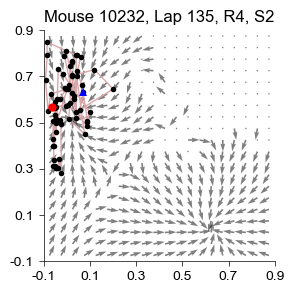

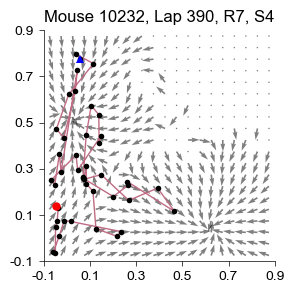

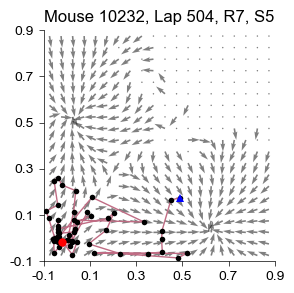

In [ ]:
def plot_lap_on_vector_field(mouse: int, is_shuf: bool = False):
    res = process_data(mouse)

    lap_traj = res['lap_traj']
    beg = np.concatenate([[0], np.where(np.diff(lap_traj) != 0)[0] + 1])
    end = np.concatenate([np.where(np.diff(lap_traj) != 0)[0] + 1, [len(lap_traj)]])
    corr_traj = res['corr_traj']
    route_traj = res['route_traj']
    session_traj = res['session_traj']
    
    if is_shuf:
        
        rand_idx = np.random.permutation(corr_traj.shape[1])
        corr_traj = corr_traj[:, rand_idx]
    
    speed_traj = res['speed_traj']
    speed_binned = np.clip(speed_traj // 10, 0, 4).astype(np.int64)
    dcorr = np.zeros_like(corr_traj) * np.nan

    for i in range(len(beg)):
        dcorr[:, beg[i]:end[i]-1] = np.diff(corr_traj[:, beg[i]:end[i]], axis=1)

    x_binned = np.clip((corr_traj[0, :] + 0.1) // 0.05, 0, 19).astype(np.int64)
    y_binned = np.clip((corr_traj[1, :] + 0.1) // 0.05, 0, 19).astype(np.int64)

    avg_dcorr = np.zeros((20, 20, 3))
    for i in range(20):
        for j in range(20):
            
            idx = np.where(
                (x_binned == i) & 
                (y_binned == j) & 
                (np.isnan(dcorr[0, :]) == False) &
                (np.isnan(dcorr[1, :]) == False)
            )[0]
            if len(idx) > 0:
                avg_dx = np.nanmean(dcorr[0, idx])
                avg_dy = np.nanmean(dcorr[1, idx])
                strength = np.sqrt(avg_dx**2 + avg_dy**2)
                avg_dcorr[i, j, 0] = avg_dx #/ strength if strength != 0 else 0
                avg_dcorr[i, j, 1] = avg_dy #/ strength if strength != 0 else 0
                avg_dcorr[i, j, 2] = strength
        
    idx0 = np.where(avg_dcorr[:, :, 0] == 0)
    idx1 = np.where(avg_dcorr[:, :, 1] == 0)
    avg_dcorr[:, :, 0] = gaussian_filter(avg_dcorr[:, :, 0], sigma=1)
    avg_dcorr[:, :, 0][idx0] = 0
    avg_dcorr[:, :, 1] = gaussian_filter(avg_dcorr[:, :, 1], sigma=1)
    avg_dcorr[:, :, 1][idx1] = 0
    strength = np.sqrt(
        avg_dcorr[:, :, 0]**2 + avg_dcorr[:, :, 1]**2
    )
    strength[strength < 1e-8] = 1e-8
    avg_dcorr[:, :, 0] /= strength
    avg_dcorr[:, :, 0][idx0] = 0
    avg_dcorr[:, :, 1] /= strength
    avg_dcorr[:, :, 1][idx1] = 0

    X, Y = np.meshgrid(np.arange(20), np.arange(20))

    for l in np.array([135, 390, 504])-1:
        if route_traj[beg[l]] not in [3, 6]:
            continue
        
        fig = plt.figure(figsize=(3, 3))
        ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
        ax.quiver(
            Y.flatten(), X.flatten(), 
            avg_dcorr[:, :, 0].flatten(), 
            avg_dcorr[:, :, 1].flatten(), 
            color='k', alpha=0.5,
            scale=20, width=0.007
        )
        ax.set_xticks(np.linspace(-0.5, 19.5, 6), [-0.1, 0.1, 0.3, 0.5, 0.7, 0.9])
        ax.set_yticks(np.linspace(-0.5, 19.5, 6), [-0.1, 0.1, 0.3, 0.5, 0.7, 0.9])
        ax.set_aspect('equal')
        ax.set_xlim(-0.5, 19.5)
        ax.set_ylim(-0.5, 19.5)
        
        ax.plot(
            (corr_traj[0, beg[l]:end[l]]+0.1)*20-0.5, 
            (corr_traj[1, beg[l]:end[l]]+0.1)*20-0.5, 
            marker='o', markersize=4,
            markeredgewidth=0,
            markerfacecolor='k',
            lw=1, c=DSPPalette[route_traj[beg[l]]]
        )
        ax.plot(
            (corr_traj[0, beg[l]:beg[l]+1]+0.1)*20-0.5, 
            (corr_traj[1, beg[l]:beg[l]+1]+0.1)*20-0.5, 
            c='red', marker='o', markersize=6, markeredgewidth=0
        )
        ax.plot(
            (corr_traj[0, end[l]-1:end[l]]+0.1)*20-0.5, 
            (corr_traj[1, end[l]-1:end[l]]+0.1)*20-0.5, 
            c='blue', marker='^', markersize=6, markeredgewidth=0
        )
        ax.set_title(f"Mouse {mouse}, Lap {l+1}, R{route_traj[beg[l]]+1}, S{session_traj[beg[l]]+1}")
        plt.savefig(join(loc, f"Example Lap [{mouse} L{l+1}].png"), dpi=600)
        plt.savefig(join(loc, f"Example Lap [{mouse} L{l+1}]].svg"), dpi=600)
        plt.show()

plot_lap_on_vector_field(10232)
    

# To Diagonal Distances vs. Speed and Session